# Лабораторная работа №6

Базовый прогон модели SIR в подходе сетей Петри

Закиров Нурислам Дамирович (РУДН)

# Введение

В этом документе выполняется базовый прогон модели SIR, заданной как
сеть Петри. Переход `infection` переводит систему по правилу
`S + I -> I + I`, а переход `recovery` описывает выздоровление `I -> R`.

# Загрузка проекта

In [1]:
using DrWatson
@quickactivate "project"

using Random
using DataFrames, CSV, Plots

include(srcdir("SIRPetri.jl"))
using .SIRPetri

# Параметры

In [2]:
β = 0.3
γ = 0.1
tmax = 100.0

R0 = reproduction_number(β, γ)
println("R0 = ", R0)

R0 = 2.9999999999999996

# Построение сети

In [3]:
net, u0, states = build_sir_network(β, γ)
println(Dict(zip(states, u0)))

Dict(:I => 10.0, :R => 0.0, :S => 990.0)

# Детерминированная симуляция


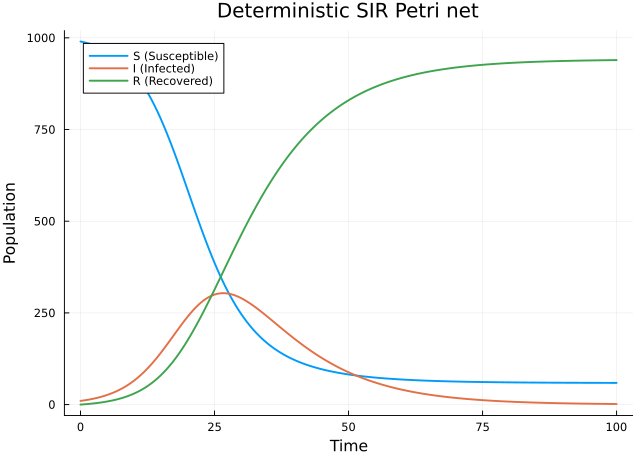

In [4]:
df_det = simulate_deterministic(net, u0, (0.0, tmax); saveat = 0.5, rates = [β, γ])
CSV.write(datadir("sir_det.csv"), df_det)

p_det = plot_sir(df_det; title = "Deterministic SIR Petri net")
savefig(p_det, plotsdir("sir_det_dynamics.png"))
p_det

# Стохастическая симуляция


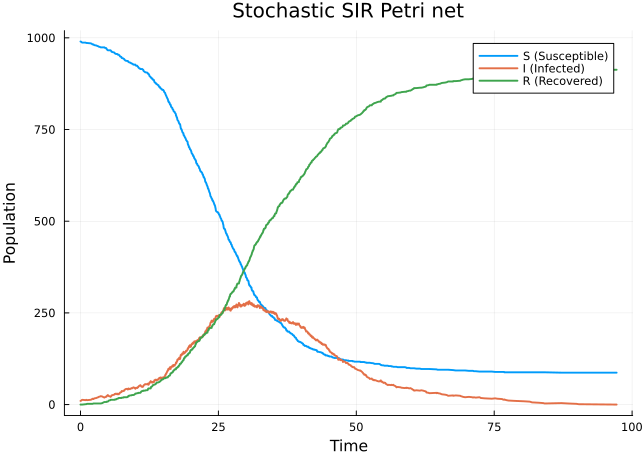

In [5]:
Random.seed!(123)
df_stoch = simulate_stochastic(net, u0, (0.0, tmax); rates = [β, γ])
CSV.write(datadir("sir_stoch.csv"), df_stoch)

p_stoch = plot_sir(df_stoch; title = "Stochastic SIR Petri net")
savefig(p_stoch, plotsdir("sir_stoch_dynamics.png"))
p_stoch

# Сравнение

In [6]:
println("Детерминированный пик I: ", maximum(df_det.I))
println("Стохастический пик I: ", maximum(df_stoch.I))

Детерминированный пик I: 303.79815890439585
Стохастический пик I: 282.0

# Вывод

Детерминированная траектория показывает усреднённую динамику эпидемии, а
стохастическая траектория демонстрирует влияние случайности. При большой
популяции обе траектории близки по форме, но могут отличаться временем и
высотой пика.